In [1]:
# Standard Libraries
import math
import os
import pickle
import random
import time
from datetime import datetime

# Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')  # For saving figures
from IPython.display import clear_output
from tqdm import tqdm

# PyTorch Libraries and Tools
import torch
import torch.nn as nn
from torch.autograd import Variable
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter

# Custom Modules (QGAN2, Discriminator, MINE)
from modules import QGAN, Discriminator, MINE
from modules.utils import convert_ipynb_to_html  # For saving HTML files
import importlib  # For reloading modules
importlib.reload(QGAN)
importlib.reload(Discriminator)
importlib.reload(MINE)

# quantum computing
import pennylane as qml

import argparse
import json

In [50]:
# args.txt 파일 경로 설정
base_dir = './runs/MNIST_0_InfoQGAN_nq8_nl50_0.4_Jan14_20_34_34'
args_file_path = f'{base_dir}/args.txt'

# args.txt 파일 읽기 및 파라미터 추출
with open(args_file_path, 'r') as file:
    args = json.load(file)

# 파라미터 설정
TARGETS = list(map(int, args["TARGETS"]))
TARGETS_STR = ''.join(map(str, TARGETS))

SEED = args["seed"]
n_qubits = args["n_qubits"]
code_qubits = args["code"]
n_layers = args["n_layers"]
img_size = int(2**(n_qubits/2))
# 출력
print(f"TARGETS: {TARGETS}")
print(f"TARGETS_STR: {TARGETS_STR}")
print(f"n_qubits: {n_qubits}")
print(f"n_layers: {n_layers}")
print(f"seed: {SEED}")

# 생성자 초기화
dev = qml.device("lightning.qubit", wires=n_qubits)

# generator 로딩
epoch = 600
generator_initial_params = torch.load(f'{base_dir}/params/generator_params_epoch{epoch}.pth')
generator = QGAN.QGAN2(n_qubits, n_qubits, n_layers, generator_initial_params, dev)


generator.params = generator_initial_params

TARGETS: [0]
TARGETS_STR: 0
n_qubits: 8
n_layers: 50
seed: 0.4


In [51]:
def generator_postprocessing(generator_output):
    # generator_output: (BATCH_SIZE, img_size**2), 값: [0,1] 범위
    # 평균과의 비율을 제곱해서 잡음제거 / 큰값 증폭 함.
    ratio = generator_output / (1 / (img_size ** 2))
    adjusted_output = (ratio ** 2) * (1 / (img_size ** 2))
    clipped_output = torch.clamp(adjusted_output, 0, 1)
    
    # max 정규화로 [0,1] 맞추기
    normalized_output = clipped_output / clipped_output.max(dim=1, keepdim=True).values
    
    return normalized_output

def generate_image(generator, seed):
    generator_output = generator.forward(seed)
    generator_output = generator_output.to(torch.float32)
    generator_output = generator_output[:, :img_size**2]
    generator_output = generator_postprocessing(generator_output)
    return generator_output

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_output2(output, code1, code2):
    #code1 은 row, code2는 column
    fig, axs = plt.subplots(10, 10, figsize=(10, 11))
    for i in range(10):
        for j in range(10):
            axs[i, j].imshow(output[i*10+j].reshape(img_size, img_size).detach().numpy(), cmap='gray')
            axs[i, j].axis('off')
    code1_name = f'code{code1}' if code1 < code_qubits else f'latent{code1-code_qubits}'
    code2_name = f'code{code2}' if code2 < code_qubits else f'latent{code2-code_qubits}'

    # x축 라벨을 위에 추가
    fig.text(0.5, 0.94, code2_name, ha='center', fontsize=12)  # x축 라벨 (위쪽)
    fig.text(0.05, 0.5, code1_name, va='center', rotation='vertical', fontsize=12)  # y축 라벨 (왼쪽)

    # x축 화살표 (위쪽으로)
    arrow_x = mpatches.FancyArrow(0.1, 0.92, 0.8, 0, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_x)

    # y축 화살표 (아래쪽으로)
    arrow_y = mpatches.FancyArrow(0.08, 0.9, 0, -0.8, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_y)

    # 제목 설정
    plt.suptitle(f"TARGETS={TARGETS_STR} nq={n_qubits} nl={n_layers} epoch={epoch} {code1_name}/{code2_name}")
    plt.savefig(f'{base_dir}/ep{epoch}_{code1_name}{code2_name}.png')
    plt.show()

def visualize_output1(output, code1, hide=False):
    #code1 은 row, code2는 column
    fig, axs = plt.subplots(10, 10, figsize=(10, 11))
    for i in range(10):
        for j in range(10):
            axs[i, j].imshow(output[i*10+j].reshape(img_size, img_size).detach().numpy(), cmap='gray')
            axs[i, j].axis('off')

    code1_name = f'code{code1}' if code1 <= code_qubits else f'latent{code1-code_qubits}'
    # x축 라벨을 위에 추가
    fig.text(0.5, 0.94, code1_name, ha='center', fontsize=12)  # x축 라벨 (위쪽)

    # x축 화살표 (위쪽으로)
    arrow_x = mpatches.FancyArrow(0.1, 0.92, 0.8, 0, width=0.01, color="black", transform=fig.transFigure)
    fig.patches.append(arrow_x)

    # 제목 설정
    plt.suptitle(f"ARGETS={TARGETS_STR} nq={n_qubits} nl={n_layers} epoch={epoch} {code1_name}")
    plt.savefig(f'{base_dir}/ep{epoch}_{code1_name}.png')
    if not hide:
        plt.show()
    plt.close()

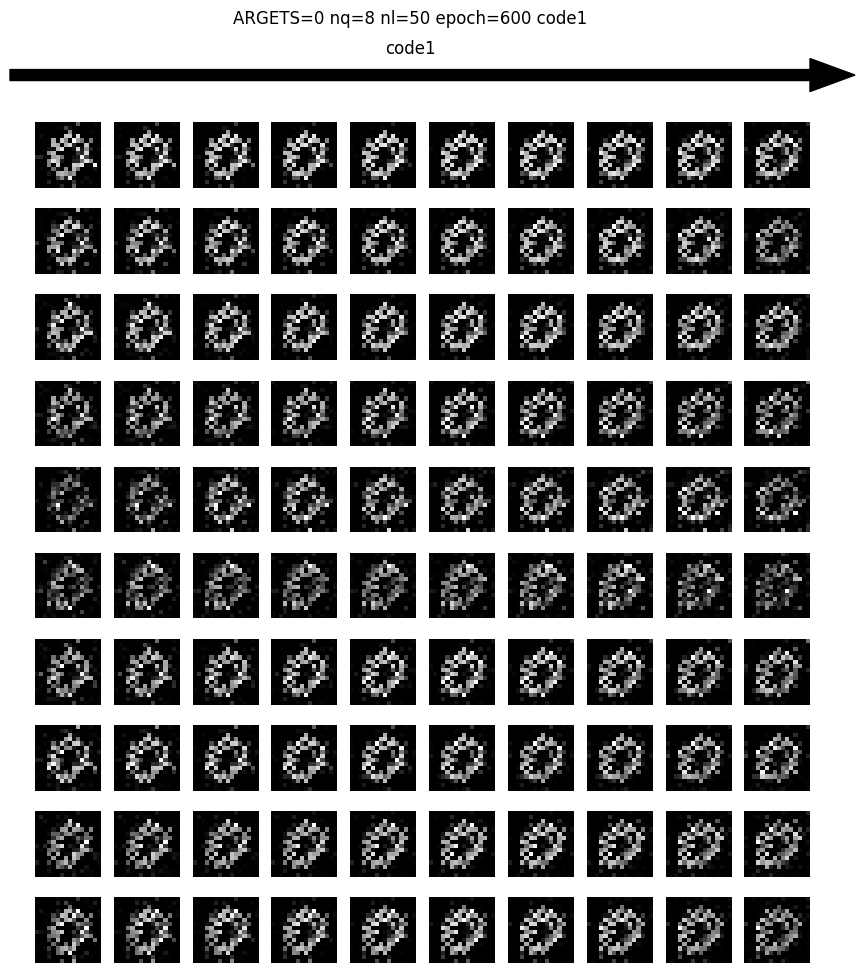

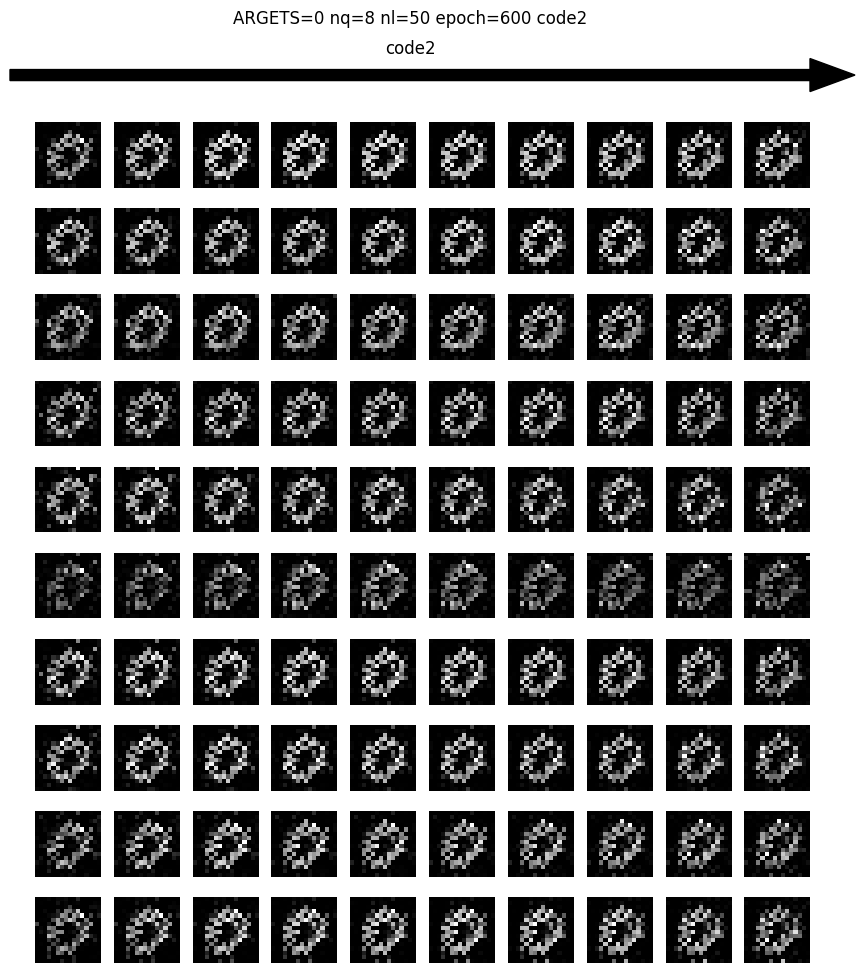

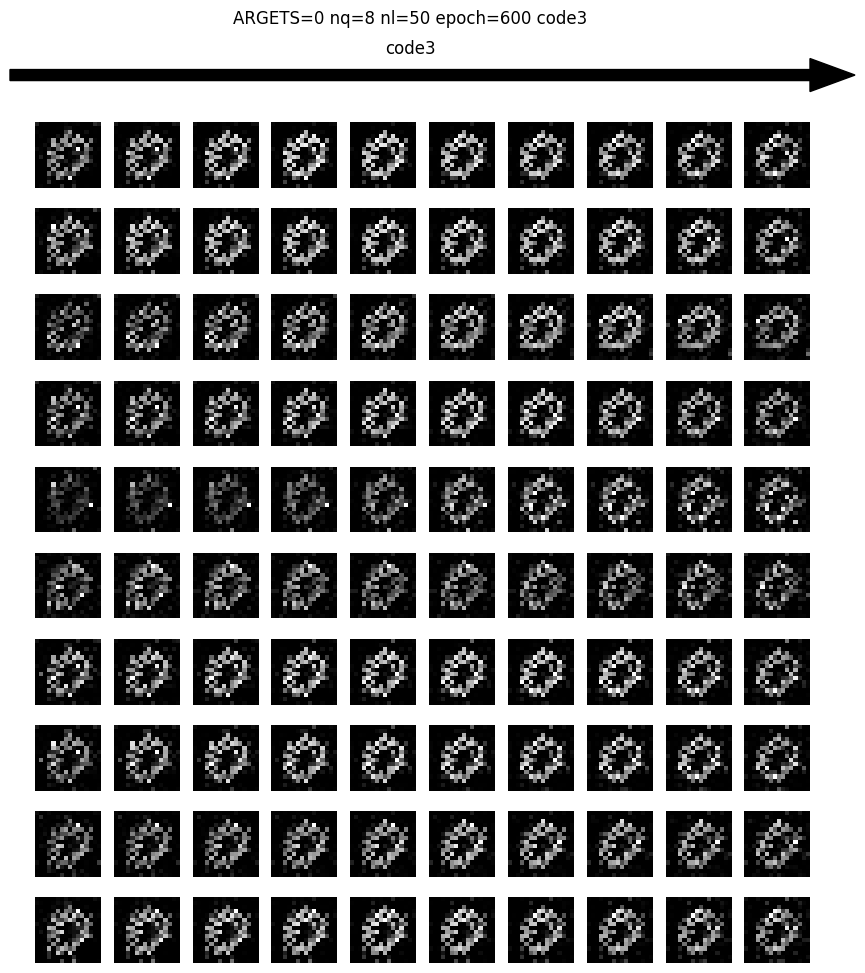

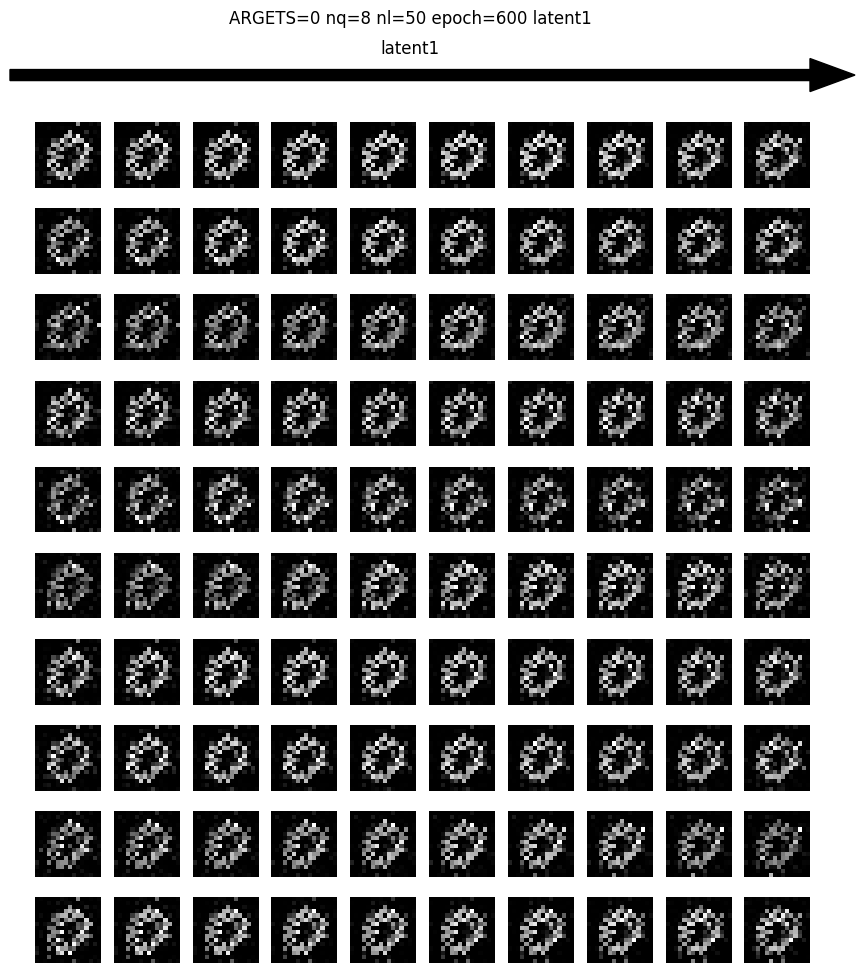

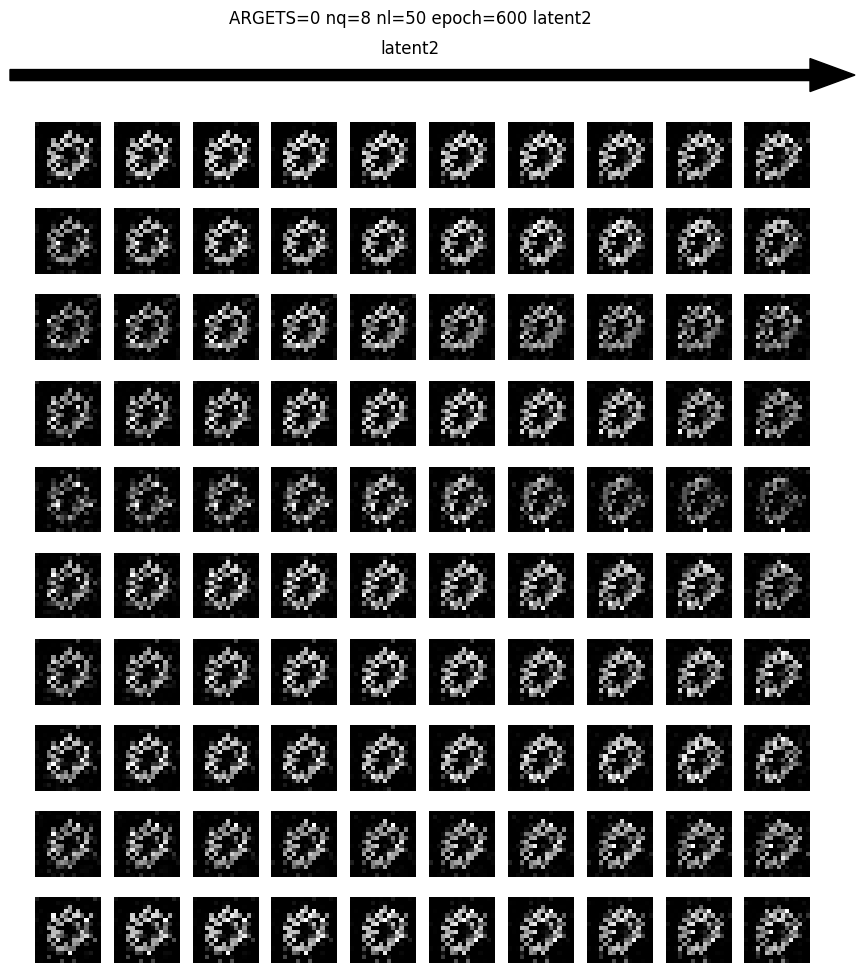

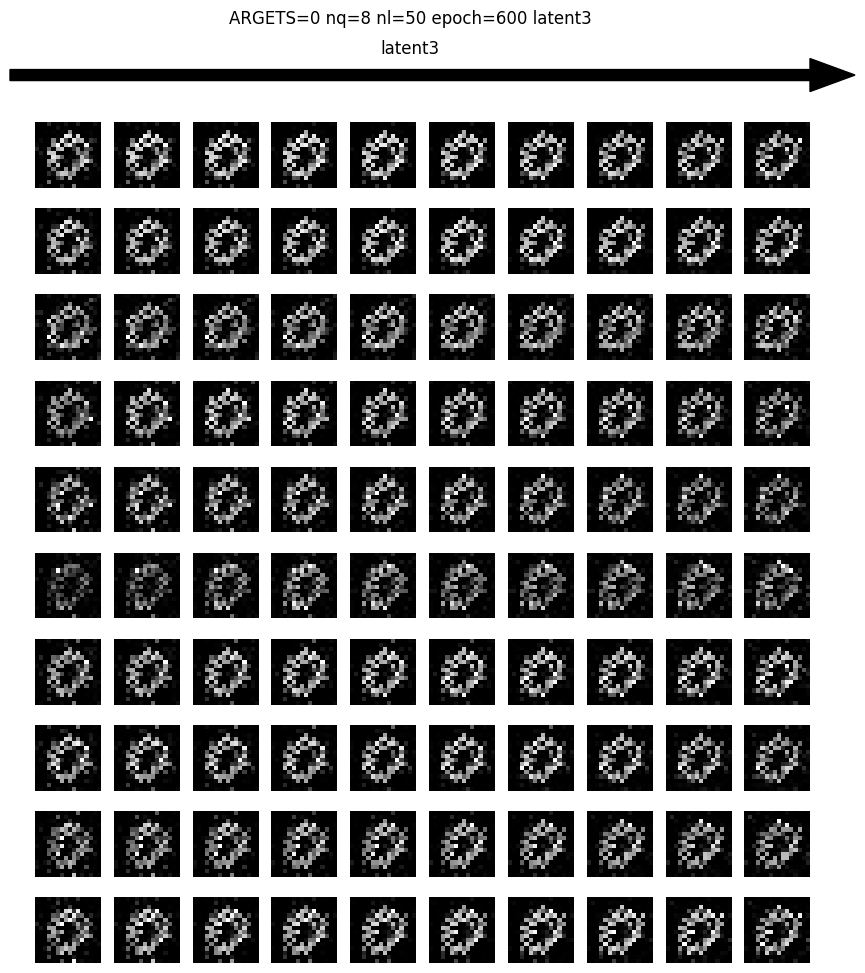

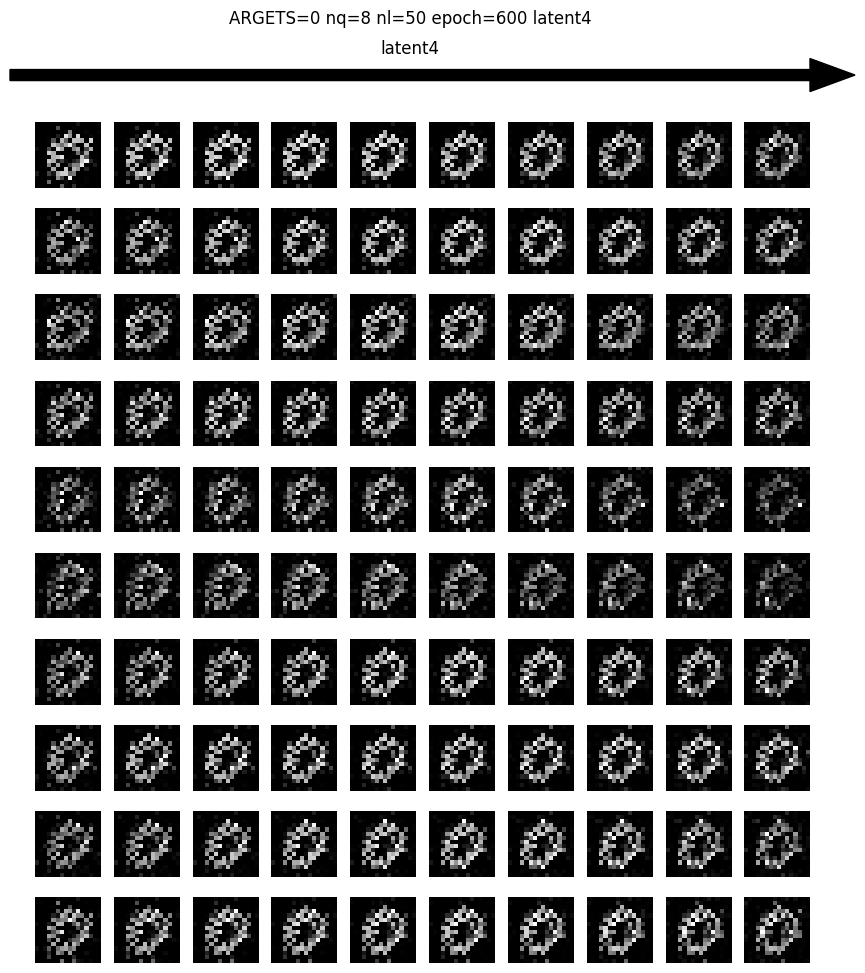

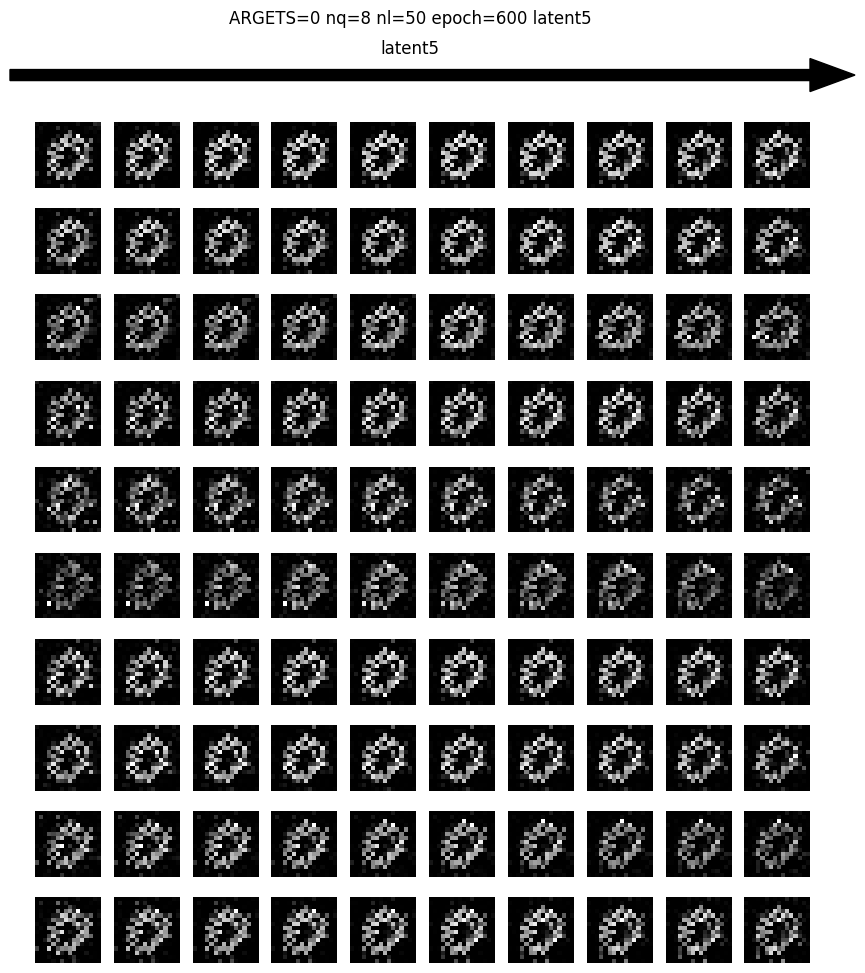

In [52]:
generator_seed = np.zeros((100, n_qubits))
# base_seed = np.random.uniform(-SEED, SEED, (10, n_qubits))
base_seed = np.random.normal(0, SEED/3, (10, n_qubits))
base_seed = np.clip(base_seed, -SEED*4, SEED*4)

for t in range(n_qubits):
    for i in range(100):
        r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
        generator_seed[i] = base_seed[r]
        generator_seed[i][t] = SEED * (-1 + 2 * c / 9)
    reconstructed = generate_image(generator, generator_seed)
    visualize_output1(reconstructed, t+1)

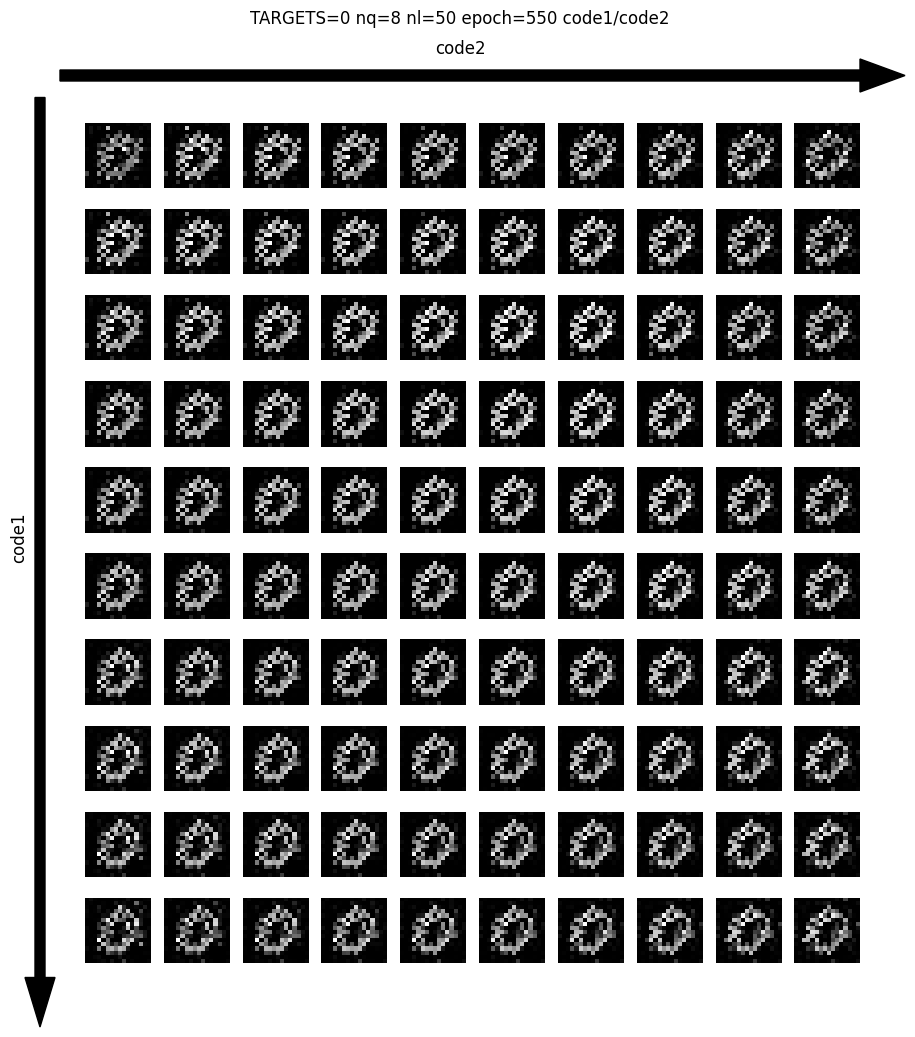

In [49]:
# generator_seed = np.random.uniform(-0.25, 0.25, (100, n_qubits)) # 원래 값 범위에서 1/4로 줄임.
generator_seed = np.zeros((100, n_qubits))

for i in range(100):
    r, c = i//10, i%10 # r, c 로 각각 -0.25 ~ 0.25 내분
    generator_seed[i, -2] = SEED * (-1 + 2 * r / 9)
    generator_seed[i, -1] = SEED * (-1 + 2 * c / 9)
reconstructed = generate_image(generator, generator_seed)
visualize_output2(reconstructed, 1, 2)